In [1]:
# AMATH 581 HW 5
# March 16, 2026
# Jonathan McCormack 

from pathlib import Path
import numpy as np
import scipy as sp
import scipy.spatial
import matplotlib.pyplot as plt
from sklearn.linear_model import Ridge
from sklearn.linear_model import LinearRegression

## Import and Preprocess Data

In [2]:

# Original data is a CSV file with each row representing a different congressman and each column representing a different attribute (party affiliation or vote)

# Attributes: 1. political party (democrat, republican), 2. handicapped-infants, 3. water-project-cost-sharing, 
#             4. adoption-of-the-budget-resolution, 5. physician-fee-freeze, 6. el-salvador-aid,
#             7. religious-groups-in-schools, 8. anti-satellite-test-ban, 9. aid-to-nicaraguan-contras,
#             10. mx-missil, 11. immigration, 12. synfuels-corporation-cutback,
#             13. education-spending, 14. superfund-right-to-sue, 15. crime, 
#             16. duty-free-exports, 17. export-administration-act-south-africa

# Political Party can be democrat (-1) or republican (+1)
# Votes can be yes (+1), no (-1), or ? (0)

# Identify current directory and path to data file
print("Current working directory:", Path.cwd())

# Load data
data = np.loadtxt(Path.cwd() / 'house-votes-84.data', delimiter=",", dtype = object, unpack=True).T
print(data.shape)

# Map votes to numeric values (+1, -1, 0)
map = {'y': 1, 'n': -1, '?': 0}
X = np.vectorize(map.get)(data[:, 1:]).astype(float)

# Map political parties: Democrats to -1, Republicans to 1
Y = data[:, 0]
Y = np.where(Y == 'democrat', -1, 1)

# Reorder X to group Democrats first, then Republicans
idx = np.argsort(Y)  # Sorts -1s before 1s
X_sort = X[idx]
Y_sort = Y[idx]

number_politicians = data.shape[0]
number_democrats = np.count_nonzero(Y_sort==-1)

del map, X, Y, idx


Current working directory: /home/jrmccormack20/Desktop/Code Repositories/AMATH 582/AMATH_582_Project_5
(435, 17)


## Necessary functions

In [3]:
# Computes the distance matrix of the X matrix using the 2 norm
dist = scipy.spatial.distance_matrix(X_sort, X_sort, p=2)


# Creates the weight matrix using Eta = e^(-(dist^2)/(2*s^2))
def weight(dist, s):
    weight = np.exp(-(dist**2)/(2*s**2))
    return weight


# Creates the unnormalized graph laplacian using the above weight function
def construct_graph_Laplacian(dist, s):
    # s is the value of sigma used to define the width of the weight distribution
    W = weight(dist, s)
    d = np.sum(W, axis=1) # degree vector
    D = np.diag(d)
    graph_laplacian = D - W # unnormalized graph laplacian
    return graph_laplacian


# define cluster accuracy function
def cluster_accuracy(predicted_party, true_party):
    n = len(true_party)
    correct = np.count_nonzero(predicted_party == true_party)
    misclassified = n-correct
    accuracy = 1-((misclassified)/n)  
    if accuracy < 0.5:
        accuracy = 1 - accuracy
    return accuracy

## Spectral Clustering

In [4]:
## Identifying the optimal sigma 

sigmas = np.arange(0.1,4,0.01)
clustering_accuracy = np.zeros(len(sigmas))

for i, sigma in enumerate(sigmas):
    L = construct_graph_Laplacian(dist, sigma)

    ll, VV = np.linalg.eigh(L) # compute eigendecompositions 

    idx = ll.argsort() # we need to sort the eigenvalues and vectors 
    l = ll[idx]
    V = VV[:, idx]
    
    fiedler_vector = V[:,1]
    sign_vector = np.sign(fiedler_vector)
    
    accuracy = cluster_accuracy(sign_vector, Y_sort)
    
    clustering_accuracy[i] = accuracy


In [5]:
print(np.argmax(clustering_accuracy))
optimal_sigma = sigmas[np.argmax(clustering_accuracy)]
print(optimal_sigma)
print(np.max(clustering_accuracy))

106
1.1599999999999995
0.8804597701149426


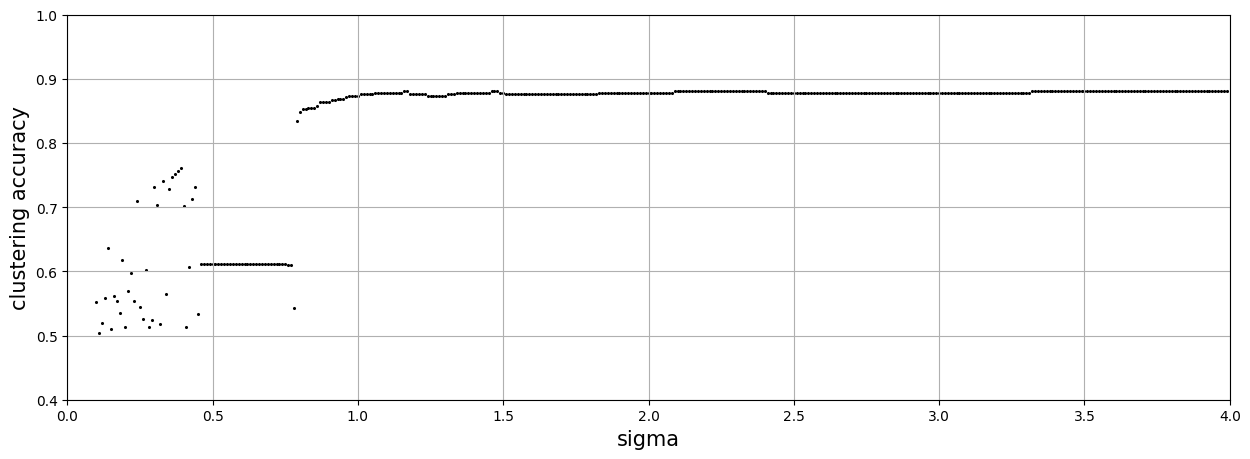

In [6]:
## Plot the improvement in clustering accuracy with the increase in sigma from 0 to 4

fig = plt.figure(figsize=(15, 5))
plt.scatter(sigmas, clustering_accuracy, s=1.5, c='k')
plt.xlabel('sigma', fontsize=15)
plt.ylabel('clustering accuracy', fontsize=15)
plt.ylim(0.4,1.0); plt.xlim(0,4.0)
plt.grid()
plt.savefig("Figure 1.png", dpi=300)
plt.show()

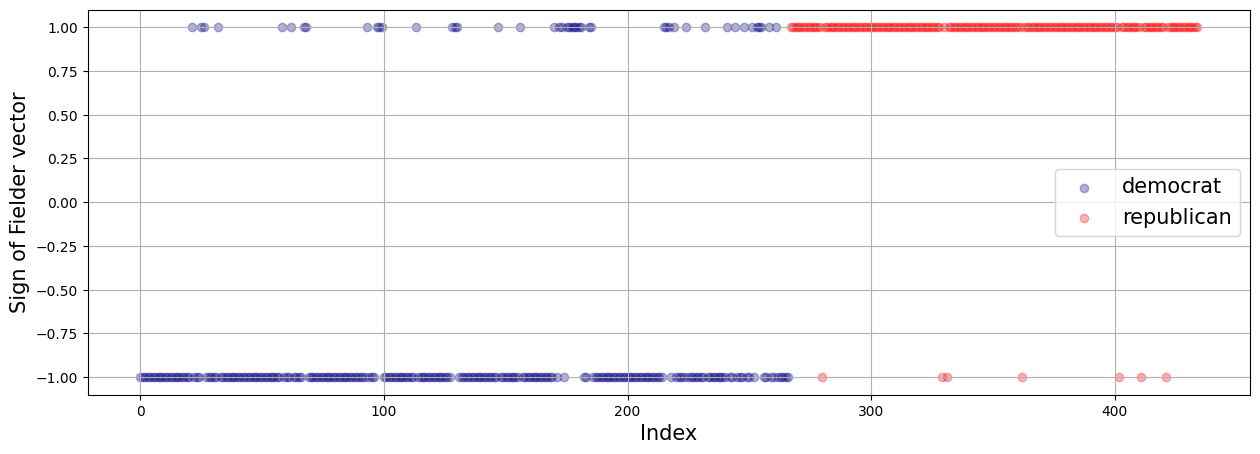

In [7]:
## Use the optimal sigma to plot the best spectral clustering model of the data

graph_laplacian = construct_graph_Laplacian(dist, optimal_sigma)

ll, VV = np.linalg.eigh(graph_laplacian) # compute eigendecompositions 
idx = ll.argsort() # we need to sort the eigenvalues and vectors 
l = ll[idx]
V = VV[:, idx]

fiedler_vector = V[:,1]
sign_vector = np.sign(fiedler_vector)

fig = plt.figure(figsize=(15, 5))
plt.scatter(np.arange(number_democrats),sign_vector[:number_democrats], alpha=0.3, c='navy', label = 'democrat')
plt.scatter(np.arange(number_democrats,number_politicians),sign_vector[number_democrats:number_politicians], alpha=0.3, c='red', label = 'republican')
plt.xlabel('Index',fontsize=15)
plt.ylabel('Sign of Fielder vector',fontsize=15)
plt.legend(fontsize=15)
plt.grid()
plt.savefig("Figure 2.png", dpi=300)
plt.show()


## Semi-supervised Learning

In [8]:
# Redo data preprocess without sorting

XX = data[:, 1:None].flatten()

ind_y = np.argwhere(XX == 'y')
ind_n = np.argwhere(XX == 'n')
ind_q = np.argwhere(XX == '?')
 
XX = np.zeros(XX.shape)

XX[ind_y] = +1
XX[ind_n] = -1
XX[ind_q] = 0 

XX = XX.reshape(number_politicians,16)

YY = data[:, 0]

ind_d = np.argwhere(YY == 'democrat')
ind_r = np.argwhere(YY == 'republican')

YY[ind_d] = -1
YY[ind_r] = +1

dist = scipy.spatial.distance_matrix(XX, XX, p=2)


In [9]:
L = construct_graph_Laplacian(dist, optimal_sigma)

ll, VV = np.linalg.eigh(L) # compute eigendecompositions 
idx = ll.argsort() # we need to sort the eigenvalues and vectors 
l = ll[idx]
V = VV[:, idx]

In [10]:
J = [5, 10, 20, 40] # number of rows from each eigenvector of the graph laplacian matrix
M = [2, 3, 4, 5, 6] # number of eigenvectors of the graph laplacian matrix  

In [11]:
## Model accuracy given various values of m and j using the optimal sigma from unsupervised learning
for j in J:
    for m in M:
        A = V[0:j, 0:m]
        b = YY[:j]
        SSLRidge = Ridge(alpha = 1e-8, fit_intercept=False)
        SSLRidge.fit(A, b)
        
        c_hat = SSLRidge.coef_
        y_pred =  np.sign(np.dot(V[:, 0:m], c_hat))
        accuracy = cluster_accuracy(y_pred, YY)
        accuracy = accuracy * 100
        
        print(f'{j}. {m}, {accuracy:.2f}')
    print ('step')
        

5. 2, 88.97
5. 3, 88.97
5. 4, 83.91
5. 5, 86.67
5. 6, 89.20
step
10. 2, 88.74
10. 3, 82.07
10. 4, 85.75
10. 5, 75.40
10. 6, 72.87
step
20. 2, 88.28
20. 3, 82.30
20. 4, 86.44
20. 5, 84.14
20. 6, 87.59
step
40. 2, 88.05
40. 3, 83.91
40. 4, 87.59
40. 5, 87.82
40. 6, 86.44
step
